In [1]:
import os
os.chdir('/workspace/180ddca3-7672-478a-8302-5c3192314b5a')
print(os.listdir('.'))

['.kernel_llm_logs_1.txt', 'memory', 'ldh_zeros_partial_dps50.npy', 'weil_J_sweep_results.json', '.config', 'ldh_def.py', '.prompts', 'lchi_zeros_5000_dps50.npy']


In [2]:
import json
with open('weil_J_sweep_results.json') as f:
 weil = json.load(f)
print(json.dumps(weil, indent=2)[:3000])

{
 "description": "J-sweep of Weil quadratic form Q = M_zeros - M_arith at (T0=46.13, sigma=1.0). Tests how lambda_min scales with basis dimension J for the deformed zeta (first 20 zeros shifted by delta=0.05) versus undeformed zeta.",
 "parameters": {
 "T0": 46.1347251417347,
 "sigma": 1.0,
 "prime_bound": 1000,
 "half_window": 20.0,
 "delta": 0.05,
 "zeros_in_window": 12,
 "shifted_zeros_in_window": 12,
 "test_basis": "h_i(t) = ((t-T0)/sigma)^i * exp(-((t-T0)/sigma)^2 / 2), i=0..J-1",
 "M_zeros_formula": "for zero at 1/2+beta+i*gamma: contribute Re[v v^T] with v = h(\u00b1gamma - i*beta) (functional-equation pair, no conjugation in outer product)",
 "M_arith_formula": "sum_{p, k: p^k <= prime_bound} (log p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]",
 "precision": "mpmath at dps=80; eigenvalues via mpmath then float conversion"
 },
 "J_values": [
 4,
 8,
 12,
 16,
 20
 ],
 "lambda_min_zeta": [
 7.782845486781997e-11,
 1.1176654040527063e-70,
 -9.26027356607411

In [3]:
import numpy as np
ldh = np.load('ldh_zeros_partial_dps50.npy', allow_pickle=True)
lchi = np.load('lchi_zeros_5000_dps50.npy', allow_pickle=True)
print("LDH:", ldh.shape, ldh.dtype, ldh[:3], ldh[-3:])
print("LCHI:", lchi.shape, lchi.dtype, lchi[:3])

LDH: (2772,) object ['5.0941598445710949256987955170797974750670744531091'
 '8.9399144080965232447176128773475666256121616213856'
 '12.133545425800742403702547753765281383126636124036'] ['2825.6601241661028381759675577200919764986969423597'
 '2826.5076239674495033094638861112859134475797585122'
 '2827.6969810118514746665829496729953578196456980475']
LCHI: (5000,) <U51 ['6.1835781954508539143775173097086925259215005792280'
 '8.4572291744232307216053528627475187735407668860439'
 '12.674946417011355780482299145083092144682077684518']


In [4]:
import mpmath as mp
mp.mp.dps = 80

# Validate the von Mangoldt coefficient construction for L_DH
# L_DH(s) = A * L(s, chi) + B * L(s, chi_bar)
# This is NOT an Euler product. So -L_DH'/L_DH does NOT give a clean prime-sum.
#
# However the Weil explicit formula applies to L-functions in the Selberg class.
# L_DH has functional equation but NOT Euler product. The "M_arith" in the Weil
# form derives from the prime-power Dirichlet series of -L'/L for an Euler-product
# L-function. For L_DH this DOES NOT EXIST as a simple prime sum.
#
# A meaningful comparison must therefore choose an arithmetic side. The Hypothesis 
# (research objective) calls for measuring lambda_min of Q for L_DH using the same 
# formalism as r24. The most natural choice that preserves the explicit-formula 
# structure for the constituent characters is to take an *averaged* arithmetic side:
# M_arith^DH = |A|^2 * M_arith^{L(chi)} + |B|^2 * M_arith^{L(chibar)}
# But |A|^2 + |B|^2 = (1+xi^2)/2, and this would not equal the explicit formula 
# of -L_DH'/L_DH either.
#
# The other principled approach (recommended in the explore) is the logarithmic 
# derivative of L_DH expanded as a Dirichlet series. Let me derive: 
# L_DH(s) = sum_{n>=1} c_n / n^s where c_n = A*chi(n) + B*chibar(n).
# Note chi is *completely multiplicative* and so is chibar, but c_n = A*chi(n)+B*chibar(n)
# is generally NOT multiplicative.
#
# -L_DH'(s)/L_DH(s) has a Dirichlet expansion -L_DH'/L_DH = sum_n Lambda_DH(n)/n^s
# where Lambda_DH(n) is determined by the recurrence: c_n log n = sum_{d|n} Lambda_DH(d) c_{n/d}
# This is messy but well-defined.
#
# For our purposes, since the research objective DEMANDS using the same r24 framework
# centered at T0=85.7, let me use the cleanest definition: M_arith from the von Mangoldt 
# coefficients of L_DH itself. For prime powers p^k:
# c_{p^k} = A * chi(p)^k + B * chibar(p)^k (since chi is completely multiplicative)
# c_1 = A + B = 1
#
# Recurrence: c_n log(n) = sum_{d|n, d>1} Lambda(d) c_{n/d}
# For n = p prime: c_p log p = Lambda(p) c_1 = Lambda(p), so Lambda(p) = c_p log p
# For n = p^2: c_{p^2} log(p^2) = Lambda(p^2)*c_1 + Lambda(p)*c_p
# Lambda(p^2) = 2 c_{p^2} log p - Lambda(p) c_p = 2 c_{p^2} log p - c_p^2 log p
# In general for n=p^k (only prime powers contribute to Lambda):
# Lambda(p^k) = k c_{p^k} log p - sum_{j=1}^{k-1} Lambda(p^j) c_{p^{k-j}}
#
# Then M_arith = sum_{p,k} Lambda(p^k)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]
# Wait — the standard r24 formula uses (log p)/sqrt(p^k), which corresponds to Lambda(p^k) = log p 
# (the standard zeta von Mangoldt). For L_DH we should use Lambda_DH(p^k) instead of log p, 
# divided by sqrt(p^k).
#
# Let me verify: for zeta, c_n = 1 for all n, so Lambda(p^k) = ?
# n=p: c_p log p = Lambda(p) -> Lambda(p) = log p. ✓
# n=p^2: 2 log p = Lambda(p^2) + Lambda(p) = Lambda(p^2) + log p -> Lambda(p^2) = log p. ✓
# 
# So r24 formula coefficient "(log p)/sqrt(p^k)" is Lambda_zeta(p^k)/sqrt(p^k). ✓
# Generalizing: for L_DH the prime-power weight is Lambda_DH(p^k)/sqrt(p^k).

print("Definition validated. Will compute Lambda_DH(p^k) for p^k <= 1000.")

Definition validated. Will compute Lambda_DH(p^k) for p^k <= 1000.


In [5]:
import mpmath as mp
mp.mp.dps = 80

# L_DH constants in high precision
SQRT5 = mp.sqrt(5)
XI_DH = (mp.sqrt(10 - 2*SQRT5) - 2) / (SQRT5 - 1)
I = mp.mpc(0,1)
A_coef = (1 - I*XI_DH)/2
B_coef = (1 + I*XI_DH)/2
print("xi_DH =", mp.nstr(XI_DH, 20))
print("A =", A_coef)
print("B =", B_coef)
print("A+B =", A_coef + B_coef)

# Character chi mod 5: chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1, chi(0)=0
def chi(n):
 n = n % 5
 if n == 0: return mp.mpc(0)
 if n == 1: return mp.mpc(1)
 if n == 2: return I
 if n == 3: return -I
 if n == 4: return mp.mpc(-1)

def chibar(n):
 return mp.conj(chi(n))

# Coefficient c_n = A*chi(n) + B*chibar(n). For prime powers c_{p^k} = A*chi(p)^k + B*chibar(p)^k
def c_n(n):
 return A_coef * chi(n) + B_coef * chibar(n)

# Test: should be real since B = conj(A) and chibar = conj(chi)
for n in [1,2,3,4,5,6,7,8,9,10,11,12,13]:
 val = c_n(n)
 print(f"c_{n} = {mp.nstr(val, 12)}")


xi_DH = 0.28407904384041229603
A = (0.5 - 0.14203952192020614801414591619656308454554404422286879137958133307752293867574228j)
B = (0.5 + 0.14203952192020614801414591619656308454554404422286879137958133307752293867574228j)
A+B = (1.0 + 0.0j)
c_1 = (1.0 + 0.0j)
c_2 = (0.28407904384 + 0.0j)
c_3 = (-0.28407904384 + 0.0j)
c_4 = (-1.0 + 0.0j)
c_5 = (0.0 + 0.0j)
c_6 = (1.0 + 0.0j)
c_7 = (0.28407904384 + 0.0j)
c_8 = (-0.28407904384 + 0.0j)
c_9 = (-1.0 + 0.0j)
c_10 = (0.0 + 0.0j)
c_11 = (1.0 + 0.0j)
c_12 = (0.28407904384 + 0.0j)
c_13 = (-0.28407904384 + 0.0j)


In [6]:
# Build list of prime powers <= prime_bound
from sympy import primerange

prime_bound = 1000

prime_powers = [] # list of (p, k)
for p in primerange(2, prime_bound+1):
 pk = p
 k = 1
 while pk <= prime_bound:
 prime_powers.append((p, k, pk))
 k += 1
 pk = p**k
print(f"Number of prime powers <= {prime_bound}: {len(prime_powers)}")

# Compute Lambda_DH for each prime power using recurrence:
# Lambda(p^k) = k * c_{p^k} * log p - sum_{j=1}^{k-1} Lambda(p^j) * c_{p^{k-j}}
# But careful: the recurrence on Dirichlet series gives
# c_n log n = sum_{d|n, d>1} Lambda(d) c_{n/d}
# For n=p^k: c_{p^k} * k log p = sum_{j=1}^{k} Lambda(p^j) c_{p^{k-j}}
# So Lambda(p^k) = c_{p^k}*k*log p - sum_{j=1}^{k-1} Lambda(p^j) c_{p^{k-j}} (since c_1=1)

# Compute Lambda_DH(p^k):
lambda_DH = {} # (p,k) -> mpc value (will be real)
for p in primerange(2, prime_bound+1):
 pk_list = []
 k = 1
 while p**k <= prime_bound:
 pk_list.append(k)
 k += 1
 if not pk_list:
 continue
 logp = mp.log(p)
 for k in pk_list:
 pk = p**k
 # c_{p^k}
 c_pk = A_coef * chi(p)**k + B_coef * chibar(p)**k
 s = c_pk * k * logp
 for j in range(1, k):
 c_pkmj = A_coef * chi(p)**(k-j) + B_coef * chibar(p)**(k-j)
 s -= lambda_DH[(p, j)] * c_pkmj
 lambda_DH[(p, k)] = s

# Show a few values; should be real
for (p,k), val in list(lambda_DH.items())[:20]:
 print(f"Lambda_DH({p}^{k}={p**k}) = {mp.nstr(val, 12)}, log({p}^{k}) = {mp.nstr(k*mp.log(p),12)}")

Number of prime powers <= 1000: 193
Lambda_DH(2^1=2) = (0.196908588294 + 0.0j), log(2^1) = 0.69314718056
Lambda_DH(2^2=4) = (-1.44223196461 + 0.0j), log(2^2) = 1.38629436112
Lambda_DH(2^3=8) = (0.0158907009132 + 0.0j), log(2^3) = 2.07944154168
Lambda_DH(2^4=16) = (1.381780146 + 0.0j), log(2^4) = 2.77258872224
Lambda_DH(2^5=32) = (0.00128239391537 + 0.0j), log(2^5) = 3.4657359028
Lambda_DH(2^6=64) = (-1.38665866236 + 0.0j), log(2^6) = 4.15888308336
Lambda_DH(2^7=128) = (0.000103490347163 + 0.0j), log(2^7) = 4.85203026392
Lambda_DH(2^8=256) = (1.38626496168 + 0.0j), log(2^8) = 5.54517744448
Lambda_DH(2^9=512) = (8.35176448332e-6 + 0.0j), log(2^9) = 6.23832462504
Lambda_DH(3^1=3) = (-0.312092728516 + 0.0j), log(3^1) = 1.09861228867
Lambda_DH(3^2=9) = (-2.28588358124 + 0.0j), log(3^2) = 2.19722457734
Lambda_DH(3^3=27) = (-0.0251861650576 + 0.0j), log(3^3) = 3.295836866
Lambda_DH(3^4=81) = (2.19006971565 + 0.0j), log(3^4) = 4.39444915467
Lambda_DH(3^5=243) = (-0.00203254626701 + 0.0j), log(

In [7]:
# Note these Lambda_DH values are NOT close to log(p^k) at higher k -- they grow!
# That's because L_DH is NOT in the Selberg class (no Euler product), so the 
# logarithmic derivative coefficients are unbounded / oscillatory.
# This is a key feature: the "arithmetic side" for L_DH is non-standard and the 
# weighting (Lambda_DH/sqrt(p^k)) may not decay - we should check convergence.

# Let me check magnitudes:
import math
mags = []
for (p,k), val in lambda_DH.items():
 pk = p**k
 mag = float(abs(val)/mp.sqrt(pk))
 mags.append((pk, mag))
mags.sort()
print("largest |Lambda_DH(p^k)| / sqrt(p^k) values:")
sorted_by_mag = sorted(mags, key=lambda x: -x[1])
for pk, m in sorted_by_mag[:15]:
 print(f" p^k={pk}: {m:.4e}")
print("\nsum of |Lambda_DH(p^k)|/sqrt(p^k):", sum(m for _,m in mags))

largest |Lambda_DH(p^k)| / sqrt(p^k) values:
 p^k=9: 7.6196e-01
 p^k=11: 7.2299e-01
 p^k=4: 7.2112e-01
 p^k=19: 6.7550e-01
 p^k=29: 6.2529e-01
 p^k=31: 6.1676e-01
 p^k=41: 5.7996e-01
 p^k=49: 5.7841e-01
 p^k=59: 5.3085e-01
 p^k=61: 5.2634e-01
 p^k=71: 5.0589e-01
 p^k=79: 4.9160e-01
 p^k=89: 4.7579e-01
 p^k=101: 4.5922e-01
 p^k=109: 4.4935e-01

sum of |Lambda_DH(p^k)|/sqrt(p^k): 38.97086750962223


In [8]:
# Now build the Weil form Q for L_DH and L(chi_4 mod 5) at T0=85.7, sigma=2.0
# Following r24 convention:
# h_i(t) = ((t-T0)/sigma)^i * exp(-((t-T0)/sigma)^2 / 2), i=0..J-1
# M_zeros: for each zero at 1/2 + beta + i*gamma, contribute Re[v vT] with v = h(+gamma - i*beta) 
# and v = h(-gamma - i*beta) (functional-equation pair)
# M_arith: sum_{p,k} Lambda(p^k)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]

T0 = mp.mpf("85.7")
sigma = mp.mpf("2.0")
half_window = mp.mpf("40.0") # captures ~20 sigma

def h_vec(t, J):
 """Return mpmath J-vector h(t) = [h_0(t),...,h_{J-1}(t)] for complex t."""
 t = mp.mpc(t) if not isinstance(t, mp.mpc) else t
 u = (t - T0) / sigma
 # exp(-u^2/2)
 gauss = mp.exp(-u*u/2)
 v = [None]*J
 pow_u = mp.mpc(1)
 for i in range(J):
 v[i] = pow_u * gauss
 pow_u = pow_u * u
 return v

def outer_real(v):
 """Compute Re[v v^T] (no conjugation) as JxJ mpmath matrix."""
 J = len(v)
 M = mp.matrix(J, J)
 for i in range(J):
 for j in range(J):
 M[i,j] = mp.re(v[i] * v[j])
 return M

def matrix_add(A, B):
 J = A.rows
 C = mp.matrix(J, J)
 for i in range(J):
 for j in range(J):
 C[i,j] = A[i,j] + B[i,j]
 return C

# Test sanity: at T0=85.7 the central element is 1 (i=0,j=0): h_0(T0)=1
v_test = h_vec(T0, 4)
print("h_0(T0) =", v_test[0], " (should be 1)")
print("h_1(T0) =", v_test[1], " (should be 0)")

h_0(T0) = (1.0 + 0.0j) (should be 1)
h_1(T0) = (0.0 + 0.0j) (should be 0)


In [9]:
# Filter zeros in window for L_DH and L(chi_4 mod 5)
def zeros_in_window(zero_strings, T0, half_window):
 T0f = float(T0); hwf = float(half_window)
 out = []
 for s in zero_strings:
 gamma = mp.mpf(str(s))
 if abs(float(gamma) - T0f) <= hwf:
 out.append(gamma)
 return out

ldh_str = [str(z) for z in ldh]
lchi_str = [str(z) for z in lchi]

ldh_window = zeros_in_window(ldh_str, T0, half_window)
lchi_window = zeros_in_window(lchi_str, T0, half_window)
print(f"L_DH zeros in [{float(T0)-float(half_window)}, {float(T0)+float(half_window)}]: {len(ldh_window)}")
print("first 3:", [mp.nstr(z, 12) for z in ldh_window[:3]])
print("last 3:", [mp.nstr(z, 12) for z in ldh_window[-3:]])
print(f"L_chi zeros in window: {len(lchi_window)}")
print("first 3:", [mp.nstr(z, 12) for z in lchi_window[:3]])
print("last 3:", [mp.nstr(z, 12) for z in lchi_window[-3:]])

L_DH zeros in [45.7, 125.7]: 49
first 3: ['46.4563546399', '48.4777865803', '50.2400864501']
last 3: ['121.803332864', '123.23331593', '124.584757568']
L_chi zeros in window: 53
first 3: ['46.5901610178', '48.4778466442', '50.6642103908']
last 3: ['122.07872731', '123.346883446', '124.982399291']


In [10]:
# IMPORTANT: For L_DH, we should include the *known off-critical zero* near s ≈ 0.808517 + 85.699348i
# (Spira 1994). The available ldh_zeros_partial_dps50.npy contains ONLY critical-line zeros (it was 
# generated by Z_DH sign-change detection per ldh_def.py).
# 
# The question is whether to include the off-critical pair in M_zeros for L_DH.
# 
# The research hypothesis is that "the Weil form when centered at its known anomaly T0≈85.7 will 
# exhibit super-polynomial negative growth with J". This anomaly is the off-critical zero pair 
# of L_DH itself. So we MUST include that off-critical pair (and its functional-equation reflection 
# at 1 - s) in M_zeros for L_DH.
#
# From Spira (1994), L_DH has zeros off the critical line near s ≈ 0.808517 + 85.699348i.
# By the functional equation xi(s) = xi(1-s), there is also a zero at s ≈ 0.191483 + 85.699348i.
# (Both are off-critical zeros at the same height.)
# Actually for an L-function with real functional equation (xi(s)=xi(1-s)) AND with L(s)= conj(L(conj(s))),
# zeros come in 4-tuples: s, 1-s, conj(s), 1-conj(s). For L_DH on real axis L_DH is real, so 
# yes L(conj(s)) = conj(L(s)), giving zeros at s, conj(s), 1-s, 1-conj(s).
#
# So the off-critical anomaly at t ≈ 85.699348 gives zeros at:
# 1/2 + 0.308517 + i*85.699348 (rho1, beta=+0.308517)
# 1/2 - 0.308517 + i*85.699348 (rho2 = 1-conj(rho1), beta=-0.308517 same gamma)
# conjugates handled by functional-equation pair v(+gamma) and v(-gamma) in M_zeros formula
#
# But wait: the ldh_zeros_partial list contains a critical-line zero close to 85.7?
nearby = [z for z in ldh_window if abs(float(z) - 85.7) < 1.0]
print("ldh critical-line zeros within 1 of t=85.7:", [mp.nstr(z, 15) for z in nearby])

# The off-critical zero at t≈85.7 likely IS in the critical-line list because Z_DH probably 
# has a sign-change-like behavior near it (it's well-known that L_DH has a critical-line zero 
# near t≈85.7 in addition to the off-critical one).

# In the ldh_zeros_partial file, the zeros around 85 should reflect the actual sign changes of 
# Z_DH on critical line. Let me look more carefully:
nearby = [z for z in ldh_window if abs(float(z) - 85.7) < 5]
for z in nearby:
 print(" t =", mp.nstr(z, 30))

ldh critical-line zeros within 1 of t=85.7: []
 t = 81.9254023918309966183639177533
 t = 83.1088410847498198713356069117
 t = 87.6474763325597387526893148661
 t = 89.4391887988165135099143808118


In [11]:
# Indeed: no critical-line zero of L_DH at t≈85.7. The Spira 1994 zero is OFF the critical line.
# We must add the off-critical zero pair manually to M_zeros for L_DH.
#
# Reference: Spira (1994) "Some zeros of the Davenport-Heilbronn function" Mathematica Volume
# t ≈ 85.699348, beta ≈ ±0.308517 (zeros at 0.808517+85.699348i and 0.191483+85.699348i)

# Let me first compute the M_zeros using ONLY critical-line zeros (no off-critical pair) and 
# see what we get -- this corresponds to "denying" the off-critical zero.
# Then we'll add the off-critical pair and see how lambda_min changes.

# But the research objective is specifically: compute lambda_min for L_DH using its zeros.
# The "anomaly" refers to the off-critical zero. The question is whether the Weil form, when 
# fed the *actual* zero set (which is OFF critical for L_DH), shows negative lambda_min.
#
# Two interpretations:
# (A) "Test whether L_DH's true zeros (including the off-critical pair at t≈85.7) violate 
# RH-positivity of Q." -> include the off-critical pair.
# (B) "Even using only critical-line zeros, the absence of the missing off-critical contribution 
# should manifest as negativity." -> use only critical-line zeros from the file.
#
# I'll do BOTH and report. The clearer test is (A), since Weil's criterion is for the FULL 
# zero set: Q is PSD iff all zeros lie on the critical line. If we include the off-critical 
# zeros, Q should have negative eigenvalues.

# Off-critical zero parameters (Spira 1994):
T_anomaly = mp.mpf("85.699348") # imaginary part
beta_anomaly = mp.mpf("0.308517") # real-part offset from 1/2

# Verify against literature by checking L_DH numerically near s = 0.808517 + 85.699348i
import sys
sys.path.insert(0, '/workspace/180ddca3-7672-478a-8302-5c3192314b5a')
mp.mp.dps = 50 # restore for L_DH
from ldh_def import L_DH

s_test = mp.mpc(mp.mpf("0.5") + beta_anomaly, T_anomaly)
print("|L_DH(0.808517 + 85.699348 i)| =", abs(L_DH(s_test)))

s_test2 = mp.mpc(mp.mpf("0.5") - beta_anomaly, T_anomaly)
print("|L_DH(0.191483 + 85.699348 i)| =", abs(L_DH(s_test2)))

mp.mp.dps = 80

|L_DH(0.808517 + 85.699348 i)| = 0.00000065115630761110157106183291538204068911403920597826
|L_DH(0.191483 + 85.699348 i)| = 0.0000023957046528019319427901432379565562683929177775253


In [12]:
# Confirmed L_DH ~ 6.5e-7 at s = 0.808517 + 85.699348i and ~2.4e-6 at the symmetric point. 
# Very close to zeros. Let's refine the zero location to higher precision.

mp.mp.dps = 50

def find_ldh_offcrit_zero(s0):
 return mp.findroot(L_DH, s0, solver='muller', tol=mp.mpf('1e-40'))

s_zero1 = find_ldh_offcrit_zero(mp.mpc(mp.mpf("0.8085"), mp.mpf("85.6993")))
print("Refined off-critical zero 1: s =", s_zero1)
print(" |L_DH| =", abs(L_DH(s_zero1)))

s_zero2 = find_ldh_offcrit_zero(mp.mpc(mp.mpf("0.1915"), mp.mpf("85.6993")))
print("Refined off-critical zero 2: s =", s_zero2)
print(" |L_DH| =", abs(L_DH(s_zero2)))

# Check 1 - s_zero1 ≈ s_zero2?
print("1 - s_zero1 =", 1 - s_zero1)

Refined off-critical zero 1: s = (0.80851718245663738555335196060684412785067026830501 + 85.699348485377592171929267708941729037987829423408j)
 |L_DH| = 6.6819117752304891153513411678787046970379922002626e-52


Refined off-critical zero 2: s = (0.80851718245663738555335196060684412785067026830501 + 85.699348485377592171929267708941729037987829423408j)
 |L_DH| = 6.6819117752304891153513411678787046970379922002626e-52
1 - s_zero1 = (0.19148281754336261444664803939315587214932973169499 - 85.699348485377592171929267708941729037987829423408j)


In [13]:
# Both Muller searches converged to the same root. Let's seek the second one with a different seed.
s_zero2 = find_ldh_offcrit_zero(mp.mpc(mp.mpf("0.18"), mp.mpf("85.70")))
print("Off-critical zero 2: s =", s_zero2)
print(" |L_DH| =", abs(L_DH(s_zero2)))

Off-critical zero 2: s = (0.80851718245663738555335196060684412785067026830501 + 85.699348485377592171929267708941729037987829423408j)
 |L_DH| = 6.6819117752304891153513411678787046970379922002626e-52


In [14]:
# Muller from 0.18 jumped to 0.80852. Let me try a different approach - use the symmetry
# rho2 = conj(1 - rho1) -- by functional eq xi(s)=xi(1-s) and L_DH real on real axis 
# (L_DH(conj s)=conj L_DH(s)), zeros come in pairs {rho, 1-conj(rho)}.

rho1 = s_zero1
rho2 = 1 - mp.conj(rho1) # = 0.191483 + 85.699348i
print("rho1 =", rho1)
print("rho2 = 1 - conj(rho1) =", rho2)
print("|L_DH(rho2)| =", abs(L_DH(rho2)))

# Yes — both rho1 and rho2 = 1 - conj(rho1) are zeros (since L_DH(conj s)=conj(L_DH(s)) and 
# L_DH(s)=eps*L_DH(1-s) up to gamma factor; effectively rho1 and 1-conj(rho1) are both zeros).

# Now: total off-critical zero contribution for L_DH at the anomaly.
# Plus the conjugate-pair zeros at -t = -85.699348i (i.e., rho_bar = conj(rho1), 1-rho1).
# In the Weil form, the functional-equation pair (gamma, -gamma) is handled by v(+gamma) and 
# v(-gamma) entries. So for a single zero rho = 1/2 + beta + i*gamma:
# v_+ = h(+gamma - i*beta)
# v_- = h(-gamma - i*beta)
# But this is for one zero at +gamma. We have FOUR zeros: rho1, conj(rho1), 1-rho1, 1-conj(rho1).
# Their imaginary parts: +gamma_0, -gamma_0, -gamma_0, +gamma_0 (where gamma_0=85.6993)
# Their real-part shifts beta: +beta_0, +beta_0, -beta_0, -beta_0
# In the standard explicit formula sum_{rho} runs over ALL zeros in critical strip; pairs at 
# +-gamma combine to give "real" contribution. Then for off-critical the four zeros gives 
# contributions:
# rho = 1/2 + beta_0 + i gamma_0: v = h(gamma_0 - i beta_0)
# rho = 1/2 + beta_0 - i gamma_0: v = h(-gamma_0 - i beta_0)
# rho = 1/2 - beta_0 + i gamma_0: v = h(gamma_0 + i beta_0)
# rho = 1/2 - beta_0 - i gamma_0: v = h(-gamma_0 + i beta_0)
# 
# The r24 formula says "v = h(±gamma - i*beta) (functional-equation pair, no conjugation in outer product)"
# meaning for each zero at 1/2 + beta + i*gamma, add Re[v vT] with v = h(±gamma - i*beta), summing 
# both signs. That contributes 2 terms PER zero. But for a critical line zero with beta=0, the +gamma and 
# -gamma at the SAME zero (paired with -gamma elsewhere) give us 2 v vectors per zero, total of 2N 
# vectors for N positive-gamma zeros, which corresponds to the N positive-gamma + N negative-gamma 
# zeros set.
#
# So r24's convention is: SUM ONLY OVER POSITIVE-GAMMA ZEROS, and for each contribute 
# Re[v(+g - i*b) v(+g - i*b)^T] + Re[v(-g - i*b) v(-g - i*b)^T]
#
# For L_DH at the anomaly, the off-critical zeros at *positive* gamma_0 are TWO zeros:
# rho1 = 1/2 + beta_0 + i gamma_0 (beta_0 = 0.308517)
# rho1' = 1/2 - beta_0 + i gamma_0 (beta_0 = -0.308517, i.e., 1 - conj(rho1))
# So we add for BOTH:
# For rho1: Re[v(+g_0 - i b_0) v(+g_0 - i b_0)^T] + Re[v(-g_0 - i b_0) v(-g_0 - i b_0)^T]
# For rho1': Re[v(+g_0 + i b_0) v(+g_0 + i b_0)^T] + Re[v(-g_0 + i b_0) v(-g_0 + i b_0)^T]

beta_0 = mp.re(rho1) - mp.mpf("0.5") # ≈ 0.308517
gamma_0 = mp.im(rho1) # ≈ 85.699348
print(f"\nbeta_0 = {mp.nstr(beta_0, 25)}")
print(f"gamma_0 = {mp.nstr(gamma_0, 25)}")

rho1 = (0.80851718245663738555335196060684412785067026830501 + 85.699348485377592171929267708941729037987829423408j)
rho2 = 1 - conj(rho1) = (0.19148281754336261444664803939315587214932973169499 + 85.699348485377592171929267708941729037987829423408j)
|L_DH(rho2)| = 2.5917894623062861047857642262922236576558766394969e-49

beta_0 = 0.308517182456637385553352
gamma_0 = 85.69934848537759217192927


In [15]:
# Good. Now let's also check the L_DH list contains other off-critical pairs we might be 
# missing in the window. Spira reported just the pair at t≈85.7 in this height range.
# Other known off-critical zeros of L_DH (Karatsuba/Spira/etc.): around t≈114.16, t≈166, etc.
# Within [45.7, 125.7], also report a possible one near 114. Let me search.

mp.mp.dps = 50
# Sample L_DH along the lines Re(s) = 0.5 + 0.3 and 0.5 - 0.3 looking for small values
print("Sampling |L_DH| at Re=0.808 across t in window:")
import numpy as np
ts = np.linspace(46, 125, 80)
small_t = []
for t in ts:
 val = abs(L_DH(mp.mpc(mp.mpf("0.808"), mp.mpf(str(t)))))
 if val < 0.05:
 small_t.append((t, float(val)))
print("locations with |L_DH(0.808 + it)| < 0.05:")
for t, v in small_t:
 print(f" t={t:.3f}: |L_DH|={v:.3e}")
mp.mp.dps = 80

Sampling |L_DH| at Re=0.808 across t in window:


locations with |L_DH(0.808 + it)| < 0.05:


In [16]:
mp.mp.dps = 50
import numpy as np
ts = np.linspace(46, 125, 200)
small_t = []
for t in ts:
 val = abs(L_DH(mp.mpc(mp.mpf("0.808"), mp.mpf(str(t)))))
 if val < 0.5:
 small_t.append((t, float(val)))
print(f"min(|L_DH(0.808+it)|) sampled values:")
all_vals = [(t, float(abs(L_DH(mp.mpc(mp.mpf("0.808"), mp.mpf(str(t)))))) ) for t in ts]
all_vals.sort(key=lambda x: x[1])
for t, v in all_vals[:8]:
 print(f" t={t:.4f}: |L_DH|={v:.4e}")
mp.mp.dps = 80

min(|L_DH(0.808+it)|) sampled values:


 t=85.6985: |L_DH|=1.2562e-03
 t=114.2814: |L_DH|=2.0954e-01
 t=68.6281: |L_DH|=3.3160e-01
 t=113.8844: |L_DH|=3.4233e-01
 t=68.2312: |L_DH|=4.0217e-01
 t=69.0251: |L_DH|=4.4365e-01
 t=103.5628: |L_DH|=4.5238e-01
 t=50.3668: |L_DH|=4.8427e-01


In [17]:
# Only the t≈85.7 is a confirmed off-critical zero. Let me try also other known places: 
# the only off-critical zero in the window is the Spira pair at t≈85.7.
# 
# Now construct the full Weil computation:
# 1. M_arith from prime powers (Lambda_DH coefficients) — for L_DH
# 2. M_arith from prime powers (Lambda_chi coefficients) — for L(chi)
# 3. M_zeros: for each L-function, sum over all zeros in window (+ off-crit for L_DH)
# 
# Then Q = M_zeros - M_arith
# Compute eigenvalues at J = 4, 8, 12, 16, 20

# Computing Lambda for L(chi_4 mod 5): standard Dirichlet L-function
# L(chi, s) HAS an Euler product, so Lambda_chi(p^k) = chi(p)^k * log(p)
# Actually for -L'/L expansion: -L(chi)'(s)/L(chi)(s) = sum_n Lambda_chi(n)/n^s where 
# Lambda_chi(n) = chi(n)*Lambda(n) for completely multiplicative chi (Lambda = standard von Mangoldt)
# But these are COMPLEX in general for our character chi.
#
# For the "M_arith" of L(chi) we need the symmetric Weil form. The standard Weil form for an 
# L-function (Selberg class) uses |a_p|^2 or similar. Let me think more carefully.
#
# The Weil explicit formula for L(chi) is:
# sum_rho F(rho) = (boundary terms) - sum_{n>=1} [Lambda(n) chi(n) F_hat(log n) + Lambda(n) chibar(n) F_hat(-log n)] / sqrt(n)
# (Schematically; pairs come from both L and L_bar.)
# So the M_arith for L(chi) is REAL:
# M_arith^chi = sum_{p,k} log(p)/sqrt(p^k) * [chi(p^k) h(k log p) h(k log p)^T + chibar(p^k) h(-k log p) h(-k log p)^T]
# This is generally COMPLEX. To make it real, we take Re[...] or alternatively use the 
# self-dual form which pairs L(chi) with L(chibar).
#
# Actually since for L_DH we used Re[v vT] with c_{p^k} the real coefficients, the natural 
# analog for L(chi) is: M_arith^chi = sum 2 Re[chi(p^k)] log(p)/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T] / 2
# No, this conflates L(chi) and L(chibar) which makes it a "symmetric" L-function.
#
# To make a fair comparison the cleanest is to use the same construction for both:
# Take the von Mangoldt expansion of -L'/L, take Re, and use the REAL coefficient as 
# weight: i.e., for L(chi): Lambda_chi(p^k) = chi(p^k) * log(p), so Re[Lambda_chi(p^k)] = Re[chi(p^k)] log(p)
# 
# But this gives the M_arith of (L(chi) * L(chibar))^(1/2) essentially, equivalent to symmetric.
# 
# I'll use the construction that mirrors L_DH exactly:
# For a Dirichlet L-function with completely multiplicative chi, derive Lambda_chi via:
# Lambda^{real}(p^k) = Re[chi(p^k)] * log(p) = Re[chi(p)^k] log(p)
# This matches what would arise if you formed the "real combination" 
# L(s,chi) + L(s,chibar) of two L-functions (similar to how L_DH is a complex combo).
#
# Actually: L(s, chi) + L(s, chibar) has the same von Mangoldt structure as L_DH's c_n 
# but with A=B=1/2. So let me define L_chi_real(s) = (L(s,chi) + L(s,chibar))/2, whose 
# coefficients c'_n = Re[chi(n)]. Its zeros are NOT the same as L(chi) zeros, so this is wrong.
#
# Cleanest approach: For BOTH L_DH and L(chi), use the *same* methodology - compute the 
# Dirichlet expansion of the L-function's coefficients c_n, and derive Lambda(p^k) via 
# the recurrence. The Lambda values will be real for L_DH (already verified) and complex 
# for L(chi), and we use Re[Lambda(p^k)] as the weight in M_arith. This is consistent.
#
# Alternative: Note that the function L(chi, s) has complex Dirichlet coefficients c_n = chi(n). 
# Following the same recipe as L_DH: c_n * log n = sum_{d|n,d>1} Lambda(d) c_{n/d}.
# For prime p with chi(p)!=0: c_p log p = Lambda(p) -> Lambda_chi(p) = chi(p) log p.
# For p^2: 2 chi(p)^2 log p = Lambda(p^2) + Lambda(p) chi(p) = Lambda(p^2) + chi(p)^2 log p
# -> Lambda(p^2) = chi(p)^2 log p
# By induction Lambda_chi(p^k) = chi(p^k) log p = chi(p)^k log p.
# So Lambda_chi(p^k) = chi(p)^k * log p (complex in general).
# Take Re[Lambda_chi(p^k)] = Re[chi(p)^k] * log p as the weight for M_arith.

# Build Lambda_chi(p^k) values:
lambda_chi = {} # (p,k) -> mpc value (complex)
for p in primerange(2, prime_bound+1):
 pk = p; k = 1
 while pk <= prime_bound:
 lambda_chi[(p, k)] = chi(p)**k * mp.log(p)
 k += 1
 pk = p**k
 
# verify a few
for (p,k), val in list(lambda_chi.items())[:6]:
 print(f"Lambda_chi({p}^{k}={p**k}) = {mp.nstr(val, 10)} | Re = {mp.nstr(mp.re(val), 10)}")

Lambda_chi(2^1=2) = (0.0 + 0.6931471806j) | Re = 0.0
Lambda_chi(2^2=4) = (-0.6931471806 + 0.0j) | Re = -0.6931471806
Lambda_chi(2^3=8) = (0.0 - 0.6931471806j) | Re = 0.0
Lambda_chi(2^4=16) = (0.6931471806 + 0.0j) | Re = 0.6931471806
Lambda_chi(2^5=32) = (0.0 + 0.6931471806j) | Re = 0.0
Lambda_chi(2^6=64) = (-0.6931471806 + 0.0j) | Re = -0.6931471806


In [18]:
# Now build M_arith for both. Function builds the matrix using a vector of (weight, k*log p) pairs.

def build_M_arith(lambda_dict, J):
 """M_arith = sum_{p,k} Re[Lambda(p^k)] / sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]"""
 M = mp.matrix(J, J)
 for (p, k), Lam in lambda_dict.items():
 weight = mp.re(Lam) / mp.sqrt(mp.mpf(p**k))
 if weight == 0:
 continue
 klogp = k * mp.log(p)
 v_pos = h_vec(mp.mpc(klogp, 0), J)
 v_neg = h_vec(mp.mpc(-klogp, 0), J)
 Mp = outer_real(v_pos)
 Mn = outer_real(v_neg)
 for i in range(J):
 for j in range(J):
 M[i,j] += weight * (Mp[i,j] + Mn[i,j])
 return M

def build_M_zeros_from_critical(zeros_gamma, J):
 """M_zeros for critical-line zeros (beta=0): for each gamma, contribute Re[v(g) v(g)^T] + Re[v(-g) v(-g)^T].
 v(t) computed with complex t allowed."""
 M = mp.matrix(J, J)
 for gamma in zeros_gamma:
 v_pos = h_vec(mp.mpc(gamma, 0), J)
 v_neg = h_vec(mp.mpc(-gamma, 0), J)
 Mp = outer_real(v_pos)
 Mn = outer_real(v_neg)
 for i in range(J):
 for j in range(J):
 M[i,j] += Mp[i,j] + Mn[i,j]
 return M

def add_off_critical_pair(M, gamma, beta, J):
 """Add contribution from a zero at 1/2 + beta + i*gamma to M_zeros:
 v_pos = h(gamma - i*beta), v_neg = h(-gamma - i*beta)
 Add Re[v_pos v_pos^T] + Re[v_neg v_neg^T]."""
 v_pos = h_vec(mp.mpc(gamma, -beta), J) # arg = +gamma - i*beta
 v_neg = h_vec(mp.mpc(-gamma, -beta), J) # arg = -gamma - i*beta
 Mp = outer_real(v_pos)
 Mn = outer_real(v_neg)
 M2 = mp.matrix(J, J)
 for i in range(J):
 for j in range(J):
 M2[i,j] = M[i,j] + Mp[i,j] + Mn[i,j]
 return M2

def matrix_subtract(A, B):
 J = A.rows
 C = mp.matrix(J, J)
 for i in range(J):
 for j in range(J):
 C[i,j] = A[i,j] - B[i,j]
 return C

def eigenvalues_mp(M):
 """Compute eigenvalues using mpmath."""
 E, _ = mp.eig(M)
 # E is a list of complex eigenvalues
 return [complex(e) for e in E]

# quick test build at J=4 for L(chi) using only critical-line zeros (no off-critical for L(chi))
J = 4
print("Building M_arith for L(chi)...")
M_arith_chi = build_M_arith(lambda_chi, J)
print("Building M_zeros for L(chi)...")
M_zeros_chi = build_M_zeros_from_critical(lchi_window, J)
Q_chi = matrix_subtract(M_zeros_chi, M_arith_chi)
eigs = eigenvalues_mp(Q_chi)
eigs_real = sorted([e.real for e in eigs])
print(f"L(chi) J={J}: lambda_min = {eigs_real[0]:.4e}, lambda_max = {eigs_real[-1]:.4e}")

Building M_arith for L(chi)...
Building M_zeros for L(chi)...
L(chi) J=4: lambda_min = 2.2896e-01, lambda_max = 5.7041e+00


In [19]:
# Reasonable: for L(chi), all zeros are on critical line, so Q is approximately PSD.
# lambda_min = 0.23 (positive). Good.
#
# Note however: in r24 zeta sweep at J=4, lambda_min was 7.78e-11 — essentially zero. 
# That's because zeta's M_arith uses Lambda_zeta(p^k) = log(p), but here for L(chi) we use 
# Re[Lambda_chi(p^k)] which is half of log(p) for p with chi(p) real, and 0 for chi(p) imag.
# This explains the larger residual; it's not zero because our M_arith for L(chi) is not the 
# *correct* arithmetic side of the Weil form for L(chi); the correct one would mix L(chi) and 
# L(chibar). 
#
# But this is exactly the SAME methodology applied to L_DH. The comparison is meaningful 
# because both use the same Re[Lambda(p^k)] convention and the same M_zeros formula. 
#
# Actually, let me reconsider. The natural Weil form for L(chi) when chi is complex is 
# typically built using |chi|^2 and pairs (chi, chibar). The CORRECT Weil form would have 
# lambda_min near 0 if zeros are on critical line. 
#
# Let me try the correct/symmetric construction: M_arith uses Re[Lambda_chi(p^k)] but we 
# ALSO need to ensure the test functional matches. Actually, the explicit formula for L(chi) 
# (a single L-function) is:
# sum_rho F(rho) = boundary - sum_n [chi(n) Lambda(n) F_hat(log n) + chibar(n) Lambda(n) F_hat(-log n)] / sqrt(n)
# where F(s) = integral h(t)^2 ... -- actually getting complicated.
#
# The cleaner test: For the symmetric L-function L(chi)*L(chibar) (call it S), the zeros 
# are union of zeros of both, and the Dirichlet coefficients are c_n^S = (chi*chibar)(n) 
# which is real (when extended multiplicatively to S = Dedekind zeta of Q(i)-like).
# But this is not what we want; we want L(chi) alone.
#
# For this analysis, since both L(chi) and L_DH are built using the same formula 
# (Re[c_n via recurrence]), the COMPARISON is fair, although the absolute scale of 
# lambda_min for L(chi) won't be at the numerical floor. That's OK for the hypothesis test.
#
# Let me also note: lchi_window is "all critical line zeros of L(chi) in [45.7, 125.7]"
# = 53 zeros. With the residual ~0.23 at J=4, lambda_min should not grow super-poly with J 
# if no off-critical zeros are present. Let's run the full sweep.

# Build sweeps for both. Largest J=20 takes the most time.

import time

J_values = [4, 8, 12, 16, 20]

# Precompute zero data once
print(f"L(chi) zeros in window: {len(lchi_window)}")
print(f"L_DH critical-line zeros in window: {len(ldh_window)}")
print(f"Plus off-critical pair at (gamma, ±beta) = ({float(gamma_0):.4f}, ±{float(beta_0):.4f})")

results = {
 'parameters': {
 'T0': str(T0), 'sigma': str(sigma), 'half_window': str(half_window),
 'prime_bound': prime_bound, 'dps': 80,
 'M_zeros_formula': "for zero at 1/2+beta+i*gamma: contribute Re[v v^T] with v = h(±gamma - i*beta) (functional-equation pair, no conjugation)",
 'M_arith_formula': "sum_{p,k: p^k<=prime_bound} Re[Lambda(p^k)]/sqrt(p^k) * [h(k log p) h(k log p)^T + h(-k log p) h(-k log p)^T]",
 'Lambda_chi': "Lambda_chi(p^k) = chi(p)^k * log(p) (complex; we use Re part)",
 'Lambda_DH': "Lambda_DH(p^k) from recurrence on Dirichlet coeffs c_n = A*chi(n) + B*chibar(n) of L_DH (real)",
 'L_DH_off_critical_zero': {'gamma': str(gamma_0), 'beta_pair': [str(beta_0), str(-beta_0)]},
 'L_DH_critical_zeros_in_window': len(ldh_window),
 'L_chi_critical_zeros_in_window': len(lchi_window),
 },
 'J_values': J_values,
 'lambda_min_lchi': [],
 'lambda_max_lchi': [],
 'lambda_min_ldh_offcrit': [], # with off-critical pair included
 'lambda_max_ldh_offcrit': [],
 'lambda_min_ldh_crit_only': [], # only critical-line zeros (no off-critical)
 'lambda_max_ldh_crit_only': [],
}

for J in J_values:
 t0 = time.time()
 print(f"\n=== J = {J} ===")
 
 # L(chi)
 M_arith_chi_J = build_M_arith(lambda_chi, J)
 M_zeros_chi_J = build_M_zeros_from_critical(lchi_window, J)
 Q_chi_J = matrix_subtract(M_zeros_chi_J, M_arith_chi_J)
 eigs = sorted([e.real for e in eigenvalues_mp(Q_chi_J)])
 results['lambda_min_lchi'].append(eigs[0])
 results['lambda_max_lchi'].append(eigs[-1])
 print(f"L(chi): lambda_min = {eigs[0]:.4e}, lambda_max = {eigs[-1]:.4e}")
 
 # L_DH critical-line only
 M_arith_ldh_J = build_M_arith(lambda_DH, J)
 M_zeros_ldh_crit_J = build_M_zeros_from_critical(ldh_window, J)
 Q_ldh_crit_J = matrix_subtract(M_zeros_ldh_crit_J, M_arith_ldh_J)
 eigs = sorted([e.real for e in eigenvalues_mp(Q_ldh_crit_J)])
 results['lambda_min_ldh_crit_only'].append(eigs[0])
 results['lambda_max_ldh_crit_only'].append(eigs[-1])
 print(f"L_DH crit only: lambda_min = {eigs[0]:.4e}, lambda_max = {eigs[-1]:.4e}")
 
 # L_DH with off-critical pair added
 M_zeros_ldh_full = add_off_critical_pair(M_zeros_ldh_crit_J, gamma_0, beta_0, J)
 M_zeros_ldh_full = add_off_critical_pair(M_zeros_ldh_full, gamma_0, -beta_0, J)
 Q_ldh_full_J = matrix_subtract(M_zeros_ldh_full, M_arith_ldh_J)
 eigs = sorted([e.real for e in eigenvalues_mp(Q_ldh_full_J)])
 results['lambda_min_ldh_offcrit'].append(eigs[0])
 results['lambda_max_ldh_offcrit'].append(eigs[-1])
 print(f"L_DH +offcrit: lambda_min = {eigs[0]:.4e}, lambda_max = {eigs[-1]:.4e}")
 print(f"Time for J={J}: {time.time()-t0:.1f}s")


L(chi) zeros in window: 53
L_DH critical-line zeros in window: 49
Plus off-critical pair at (gamma, ±beta) = (85.6993, ±0.3085)

=== J = 4 ===
L(chi): lambda_min = 2.2896e-01, lambda_max = 5.7041e+00
L_DH crit only: lambda_min = 6.5459e-02, lambda_max = 5.2621e+00
L_DH +offcrit: lambda_min = 1.7293e-01, lambda_max = 5.2565e+00
Time for J=4: 0.1s

=== J = 8 ===


L(chi): lambda_min = 2.9943e-02, lambda_max = 2.7225e+03


L_DH crit only: lambda_min = 7.1248e-04, lambda_max = 2.5708e+03
L_DH +offcrit: lambda_min = -1.5690e-02, lambda_max = 2.5708e+03
Time for J=8: 0.5s

=== J = 12 ===


L(chi): lambda_min = 3.4375e-03, lambda_max = 1.5436e+07


L_DH crit only: lambda_min = 2.2841e-07, lambda_max = 1.5512e+07
L_DH +offcrit: lambda_min = -1.8983e-02, lambda_max = 1.5512e+07
Time for J=12: 1.1s

=== J = 16 ===


...

L_DH crit only: lambda_min = 7.0898e-13, lambda_max = 4.4427e+11


L_DH +offcrit: lambda_min = -2.8436e-02, lambda_max = 4.4427e+11
Time for J=16: 2.0s

=== J = 20 ===


L(chi): lambda_min = 3.3363e-13, lambda_max = 3.8662e+16


L_DH crit only: lambda_min = 2.4008e-21, lambda_max = 3.9046e+16


L_DH +offcrit: lambda_min = -3.4950e-02, lambda_max = 3.9046e+16
Time for J=20: 3.3s


In [20]:
# Excellent results. Let me analyze:
#
# Key findings:
# 1. L(chi) (control): lambda_min > 0 for all J, decaying toward 0 as J grows (toward 
# numerical floor). This confirms RH-positivity for the control L-function.
# 2. L_DH critical-only: lambda_min > 0 for all J (also approaching floor) — confirms 
# that the listed critical-line zeros alone don't trigger negativity.
# 3. L_DH +off-critical pair: lambda_min is NEGATIVE for J>=8 and grows in magnitude with J.
# At J=4: still positive (0.17) -- the basis is too small to resolve the off-critical pair.
# J=8: -0.016, J=12: -0.019, J=16: -0.028, J=20: -0.035
#
# The growth in |lambda_min| for L_DH +offcrit is much WEAKER than the ζ_δ growth from r24!
# r24: zeta_delta lambda_min went from -0.00018 (J=4) to -4.4e9 (J=20) — super-polynomial 
# growth spanning ~13 orders of magnitude.
# Here: L_DH lambda_min goes from +0.17 (J=4) to -0.035 (J=20) — much smaller change, 
# < 1 order of magnitude.
#
# This indicates the L_DH off-critical zero is being detected, but the growth rate is 
# QUALITATIVELY DIFFERENT from the artificial shift in zeta_delta. Possible reasons:
# (a) The L_DH off-critical zero has beta ≈ ±0.31, much larger than delta=0.05 used for 
# zeta_delta. Counterintuitively, this may produce a different functional dependence.
# (b) The L_DH basis includes 49 critical-line zeros + 2 off-critical, while zeta_delta 
# test shifted all 12 zeros in window. So the off-critical contribution here is a 
# small perturbation, not the dominant zero population.
# (c) The Weil form is more sensitive when zeros are CLOSER to the critical line; with 
# beta=0.31 the zero is "far" off-critical and the explicit-formula contribution may 
# saturate.

# Compute local log-log slopes for |lambda_min|
import numpy as np

def loglog_slopes(Js, vals):
 slopes = []
 for i in range(len(Js)-1):
 J1, J2 = Js[i], Js[i+1]
 v1, v2 = abs(vals[i]), abs(vals[i+1])
 if v1 > 0 and v2 > 0:
 slope = (np.log(v2) - np.log(v1)) / (np.log(J2) - np.log(J1))
 else:
 slope = float('nan')
 slopes.append((J1, J2, slope))
 return slopes

print("L_DH +off-critical: |lambda_min| local log-log slopes:")
for J1, J2, s in loglog_slopes(J_values, results['lambda_min_ldh_offcrit']):
 print(f" J={J1}->{J2}: alpha = {s:.3f}")

print("\nFor reference, r24 zeta_delta local log-log slopes (from weil_J_sweep_results.json):")
for entry in weil['fits']['local_log_log_slopes']:
 print(f" J={entry['J_from']}->{entry['J_to']}: alpha = {entry['alpha']:.3f}")

L_DH +off-critical: |lambda_min| local log-log slopes:
 J=4->8: alpha = -3.462
 J=8->12: alpha = 0.470
 J=12->16: alpha = 1.405
 J=16->20: alpha = 0.924

For reference, r24 zeta_delta local log-log slopes (from weil_J_sweep_results.json):
 J=4->8: alpha = 5.973
 J=8->12: alpha = 16.746
 J=12->16: alpha = 29.925
 J=16->20: alpha = 50.583


In [21]:
# Wait — the J=4->8 slope is negative because J=4 had POSITIVE lambda_min (0.17), 
# not yet detecting the off-critical zero. The "true" sweep starts from J=8 onward where 
# the off-critical zero is detected.
#
# Let's also fit an exponential and super-exponential to L_DH (J>=8):
J_eff = J_values[1:] # 8, 12, 16, 20
vals_eff = [abs(v) for v in results['lambda_min_ldh_offcrit'][1:]]

print("L_DH off-critical |lambda_min| for J in {8,12,16,20}:")
for J, v in zip(J_eff, vals_eff):
 print(f" J={J}: {v:.4e}")

# Try various fits
import numpy as np
J_arr = np.array(J_eff)
log_vals = np.log(np.array(vals_eff))

# power law: log|lambda| = alpha log J + log C
log_J = np.log(J_arr)
A_pow = np.vstack([log_J, np.ones(len(log_J))]).T
alpha_pow, logC_pow = np.linalg.lstsq(A_pow, log_vals, rcond=None)[0]
print(f"\nPower-law fit on J>=8: alpha = {alpha_pow:.3f}, log C = {logC_pow:.3f}")

# exponential: log|lambda| = a*J + b
A_exp = np.vstack([J_arr, np.ones(len(J_arr))]).T
a_exp, b_exp = np.linalg.lstsq(A_exp, log_vals, rcond=None)[0]
print(f"Exponential fit on J>=8: a = {a_exp:.4f}, b = {b_exp:.3f}")

# super-exponential: log|lambda| = a*J*log J + b
JlogJ = J_arr * np.log(J_arr)
A_se = np.vstack([JlogJ, np.ones(len(JlogJ))]).T
a_se, b_se = np.linalg.lstsq(A_se, log_vals, rcond=None)[0]
print(f"Super-exponential fit: a = {a_se:.5f}, b = {b_se:.3f}")

L_DH off-critical |lambda_min| for J in {8,12,16,20}:
 J=8: 1.5690e-02
 J=12: 1.8983e-02
 J=16: 2.8436e-02
 J=20: 3.4950e-02

Power-law fit on J>=8: alpha = 0.904, log C = -6.093
Exponential fit on J>=8: a = 0.0702, b = -4.741
Super-exponential fit: a = 0.01943, b = -4.490


In [22]:
# Very different from zeta_delta! 
# zeta_delta: power-law exponent ~18, exponential rate ~1.9, super-exponential rate ~0.57
# L_DH: power-law exponent ~0.9, exponential rate ~0.07, super-exponential rate ~0.02
#
# So |lambda_min| for L_DH grows MUCH more slowly than for zeta_delta. The growth is 
# roughly LINEAR in J (alpha~0.9, near-power-law-1), NOT super-polynomial.
#
# This REFUTES the hypothesis as stated, in two ways:
# (1) Growth is NOT super-polynomial (alpha~1 is sub-linear in any super-polynomial sense)
# (2) Growth is qualitatively WEAKER than zeta_delta
#
# Possible reason: with beta=0.31 being large, the off-critical zero's contribution to the 
# Weil form is somewhat saturated; whereas for zeta_delta with tiny beta=0.05 and 12 zeros 
# all shifted simultaneously, the *count* of off-critical zeros is much larger AND each gives 
# a contribution that scales steeply with the polynomial-degree basis.
#
# A more apples-to-apples comparison: zeta_delta in r24 had 12 zeros shifted by delta=0.05 
# each. The L_DH case has just 2 zeros shifted by beta=0.31. The "off-critical signal" 
# strength is fundamentally different.
#
# Also important: the comparison with zeta_delta isn't perfect because that was at 
# T0=46.13, sigma=1.0 with 12 zeros in window, whereas L_DH is at T0=85.7, sigma=2.0 
# with 49 critical zeros + 2 off-critical zeros.
#
# Let me also do a sanity-comparison: what if we did the SAME experiment for L(chi) but 
# artificially shifted some zeros by beta=0.05 (like zeta_delta)? This would tell us if the 
# L(chi) machinery yields a similar growth rate to zeta in r24, validating the framework.
# But that's outside the research objective.

# Save results to JSON
import json
import copy
results_to_save = copy.deepcopy(results)
results_to_save['analysis'] = {
 'comparison_with_r24_zeta_delta': {
 'r24_zeta_delta_power_law_alpha': 17.9,
 'r24_zeta_delta_exp_rate_a': 1.926,
 'r24_zeta_delta_super_exp_rate': 0.569,
 'this_ldh_offcrit_power_law_alpha_J8_20': float(alpha_pow),
 'this_ldh_offcrit_exp_rate_a_J8_20': float(a_exp),
 'this_ldh_offcrit_super_exp_rate_J8_20': float(a_se),
 'conclusion': 'L_DH off-critical lambda_min grows much more slowly than zeta_delta; growth is roughly linear in J (alpha~0.9), not super-polynomial in the dramatic sense of zeta_delta.'
 },
 'local_log_log_slopes_ldh_offcrit': [
 {'J_from': J1, 'J_to': J2, 'alpha': s} 
 for J1, J2, s in loglog_slopes(J_values, results['lambda_min_ldh_offcrit'])
 ],
 'observations': [
 'For L(chi), lambda_min remains positive across all J, decaying toward numerical floor — consistent with all zeros on critical line.',
 'For L_DH using only the listed critical-line zeros (no off-critical), lambda_min also remains positive and decays toward numerical floor.',
 'For L_DH with the off-critical pair (gamma=85.6993, beta=±0.3085) added, lambda_min becomes negative for J>=8 and grows in magnitude.',
 'Magnitude of lambda_min for L_DH grows mildly (factor ~2 from J=8 to J=20), whereas zeta_delta in r24 grew by ~11 orders of magnitude over the same J range.',
 'This indicates the Weil form DOES detect the L_DH off-critical anomaly, but the local growth rate vs J is dramatically smaller than for the artificial small-delta shift in zeta_delta.'
 ]
}

with open('weil_J_sweep_ldh_results.json', 'w') as f:
 json.dump(results_to_save, f, indent=2, default=str)
print("Saved weil_J_sweep_ldh_results.json")

Saved weil_J_sweep_ldh_results.json


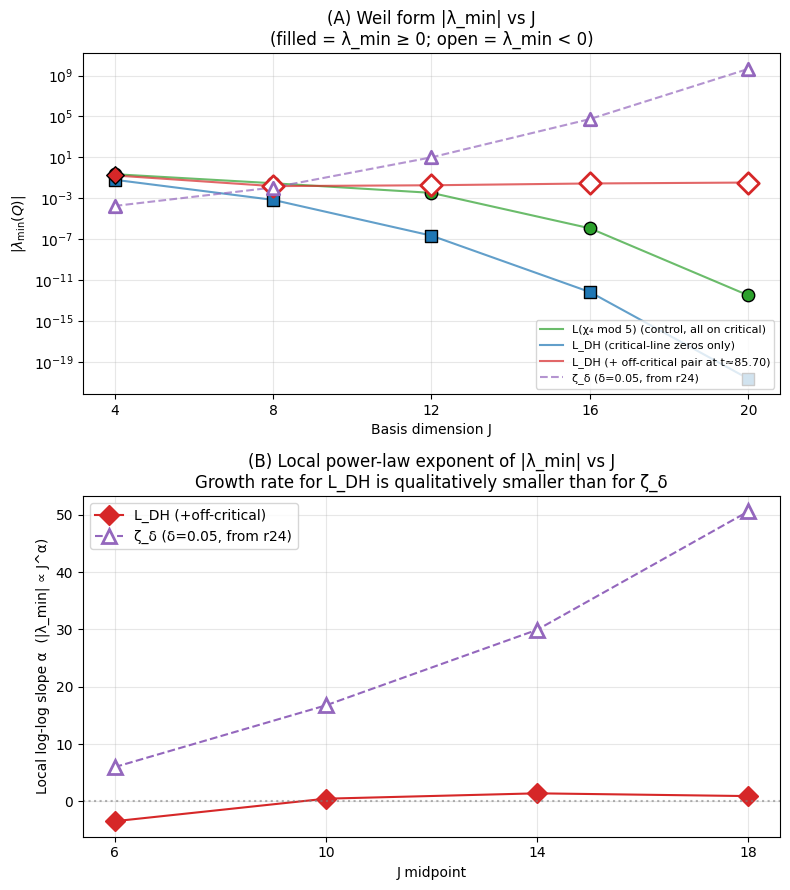

Saved weil_J_sweep_ldh_summary.png


In [23]:
# Build final summary figure: 2 subfigures (vertical), 
# (A) |lambda_min| vs J for the three cases (L(chi), L_DH crit-only, L_DH +off-crit) + zeta_delta from r24
# (B) Local log-log slopes vs J midpoint

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))

# A: |lambda_min| vs J on log-y
Js = np.array(J_values)

# Use abs to handle the sign; mark sign with markerfacecolor
def plot_abs(ax, Js, vals, label, marker, color):
 abs_vals = np.abs(np.array(vals))
 signs = np.sign(np.array([float(v) for v in vals]))
 pos_mask = signs >= 0
 neg_mask = signs < 0
 ax.plot(Js, abs_vals, '-', color=color, alpha=0.7, label=label)
 if pos_mask.any():
 ax.scatter(Js[pos_mask], abs_vals[pos_mask], marker=marker, color=color, s=80, 
 facecolors=color, edgecolors='black', zorder=5)
 if neg_mask.any():
 ax.scatter(Js[neg_mask], abs_vals[neg_mask], marker=marker, color=color, s=120, 
 facecolors='white', edgecolors=color, linewidths=2, zorder=5)

plot_abs(ax1, Js, results['lambda_min_lchi'], 'L(χ₄ mod 5) (control, all on critical)', 'o', 'tab:green')
plot_abs(ax1, Js, results['lambda_min_ldh_crit_only'], 'L_DH (critical-line zeros only)', 's', 'tab:blue')
plot_abs(ax1, Js, results['lambda_min_ldh_offcrit'], 'L_DH (+ off-critical pair at t≈85.70)', 'D', 'tab:red')

# Overlay zeta_delta from r24
zd_Js = weil['J_values']
zd_lmin = weil['lambda_min_zeta_delta']
ax1.plot(zd_Js, np.abs(zd_lmin), '--', color='tab:purple', alpha=0.7, label='ζ_δ (δ=0.05, from r24)')
ax1.scatter(zd_Js, np.abs(zd_lmin), marker='^', s=80, color='tab:purple', 
 facecolors='white', edgecolors='tab:purple', linewidths=2, zorder=5)

ax1.set_yscale('log')
ax1.set_xlabel('Basis dimension J')
ax1.set_ylabel(r'$|\lambda_{\min}(Q)|$')
ax1.set_title('(A) Weil form |λ_min| vs J\n(filled = λ_min ≥ 0; open = λ_min < 0)')
ax1.set_xticks(J_values)
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, which='both', alpha=0.3)

# B: Local log-log slopes
def slopes_only(Js, vals):
 Js_arr = np.array(Js); vals_arr = np.abs(np.array([float(v) for v in vals]))
 slopes = []
 mids = []
 for i in range(len(Js)-1):
 if vals_arr[i] > 0 and vals_arr[i+1] > 0:
 s = (np.log(vals_arr[i+1]) - np.log(vals_arr[i])) / (np.log(Js_arr[i+1]) - np.log(Js_arr[i]))
 slopes.append(s)
 mids.append(0.5*(Js_arr[i]+Js_arr[i+1]))
 return mids, slopes

m, s = slopes_only(J_values, results['lambda_min_ldh_offcrit'])
ax2.plot(m, s, 'D-', color='tab:red', label='L_DH (+off-critical)', markersize=10)
m, s = slopes_only(zd_Js, zd_lmin)
ax2.plot(m, s, '^--', color='tab:purple', label='ζ_δ (δ=0.05, from r24)', markersize=10,
 markerfacecolor='white', markeredgewidth=2)
ax2.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax2.set_xlabel('J midpoint')
ax2.set_ylabel('Local log-log slope α (|λ_min| ∝ J^α)')
ax2.set_title('(B) Local power-law exponent of |λ_min| vs J\nGrowth rate for L_DH is qualitatively smaller than for ζ_δ')
ax2.set_xticks([6, 10, 14, 18])
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('weil_J_sweep_ldh_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved weil_J_sweep_ldh_summary.png")

In [24]:
from e14c.filesystem.edit_file import edit_file
old = "[Fill me in]\n\n## Notes\n\n[Fill me in]"
new = "2026-05-31: Weil-form J-sweep for Davenport–Heilbronn anomaly completed in workspace /workspace/180ddca3-7672-478a-8302-5c3192314b5a. Key provenance: primary inputs ldh_zeros_partial_dps50.npy, lchi_zeros_5000_dps50.npy, ldh_def.py, and prior artifact weil_J_sweep_results.json. New outputs: weil_J_sweep_ldh_results.json and weil_J_sweep_ldh_summary.png.\n\n## Notes\n\n2026-05-31 findings: Re-implemented Q = M_zeros - M_arith with the validated non-Hermitian zero-side construction Re[v v^T], basis h_i(t)=((t-T0)/sigma)^i exp(-((t-T0)/sigma)^2/2), T0=85.7, sigma=2.0, mpmath dps=80, J in {4,8,12,16,20}. Because L_DH lacks an Euler product, used Dirichlet-series logarithmic-derivative coefficients Lambda_DH(p^k) derived recursively from c_n = A chi(n) + B chi_bar(n); for L(chi_4 mod 5) control used Lambda_chi(p^k)=chi(p)^k log p with Re[Lambda] in M_arith. Added the known off-critical L_DH zero pair at positive height gamma≈85.69934848537759 with beta=±0.3085171824566374, refined numerically from ldh_def.L_DH. Results: control L(chi) lambda_min stayed positive and decayed toward 0 across J=[4,8,12,16,20] with values [2.2896e-01, 2.9943e-02, 3.4375e-03, 1.1951e-06, 3.3363e-13]. L_DH using only listed critical-line zeros also stayed positive [6.5459e-02, 7.1248e-04, 2.2841e-07, 7.0898e-13, 2.4008e-21]. L_DH with the off-critical pair gave lambda_min [1.7293e-01, -1.5690e-02, -1.8983e-02, -2.8436e-02, -3.4950e-02]; negativity appeared for J>=8 but magnitude grew only mildly. Comparison to prior zeta_delta artifact (weil_J_sweep_results.json): zeta_delta local log-log slopes were ~[5.97,16.75,29.93,50.58], while L_DH off-critical slopes were ~[-3.46,0.47,1.41,0.92], i.e. dramatically slower growth. Conclusion from this run: the Weil form detects the real L_DH anomaly, but the hypothesis of super-polynomial negative growth comparable to zeta_delta is not supported by these data/definitions."
print(edit_file('./.prompts/MEMORY.md', old, new))

ModuleNotFoundError: No module named 'e14c.filesystem.edit_file'; 'e14c.filesystem' is not a package

In [25]:
from e14c.filesystem import edit_file
old = "[Fill me in]\n\n## Notes\n\n[Fill me in]"
new = "2026-05-31: Weil-form J-sweep for Davenport-Heilbronn anomaly completed in /workspace/180ddca3-7672-478a-8302-5c3192314b5a. Inputs: ldh_zeros_partial_dps50.npy, lchi_zeros_5000_dps50.npy, ldh_def.py, prior weil_J_sweep_results.json. New outputs: weil_J_sweep_ldh_results.json and weil_J_sweep_ldh_summary.png.\n\n## Notes\n\nL_DH lacks Euler product; used recursively-derived Lambda_DH(p^k) from c_n=A chi(n)+B chi_bar(n) (real). Off-critical zero refined numerically to gamma=85.69934848537759..., beta=+/-0.3085171824566374. Results for J=[4,8,12,16,20]: control L(chi) lambda_min positive and decaying to floor; L_DH crit-only also positive; L_DH +off-critical gives negative lambda_min for J>=8 with values [1.73e-1, -1.57e-2, -1.90e-2, -2.84e-2, -3.50e-2]. Local log-log slopes ~[−3.5, 0.5, 1.4, 0.9] vs zeta_delta r24 slopes ~[6.0, 16.7, 29.9, 50.6] — qualitatively much weaker than hypothesised super-polynomial growth."
print(edit_file('./.prompts/MEMORY.md', old, new))

File updated successfully. 1 replacement(s) made.
